In [43]:
%matplotlib inline 
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l


batch_size, num_steps = 32, 35


# 1. 实例化 TimeMachine 类
data = d2l.TimeMachine(batch_size=32, num_steps=35)

# 2. 获取词表 (Vocab 对象)
vocab = data.vocab

# 3. 获取数据迭代器
# 如果你使用的是新版 d2l 的 Trainer，通常直接传入 data 对象即可。
# 如果你需要手动获取 DataLoader 进行 for 循环遍历：
train_iter = data.get_dataloader(train=True)


In [44]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)

    def three():
        return (normal((num_inputs, num_hiddens)), normal((num_hiddens, num_hiddens)), torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three()
    W_xr, W_hr, b_r = three()
    W_xh, W_hh, b_h = three()

    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)

    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]

    for param in params:
        param.requires_grad_(True)

    return params


In [45]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

In [46]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params

    H, = state
    outputs = []

    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.sigmoid((X @ W_xh) + ((R * H) @ W_hh) + b_h)

        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)

    return torch.cat(outputs, dim=0), (H, )

In [47]:
class RNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device, get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn

    def __call__(self, X, state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)



In [48]:
def predict_ch8(prefix, num_preds, net, vocab, device):
    state = net.begin_state(batch_size=1, device=device)

    outputs = [vocab[prefix[0]]]

    get_inputs = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))

    for y in prefix[1:]:
        _, state = net(get_inputs(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_inputs(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ' '.join([vocab.idx_to_token[i] for i in outputs])


def grad_clipping(net, theta):
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm
    

In [49]:
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)

    for X, Y in train_iter:
        reset_state = False
        if state is not None:
            if isinstance(state, tuple):
                state_batch = state[0].shape[0] if len(state[0].shape) == 2 else state[0].shape[1]
            else:
                state_batch = state.shape[0] if len(state.shape) == 2 else state.shape[1]

            if state_batch != X.shape[0]:
                reset_state = True

        if state is None or use_random_iter or reset_state:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()

        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)

        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] /  timer.stop()


def train_ch8(net, train_iter, vocab, lr, num_epochs, device, use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', legend=['train'], xlim=[10, num_epochs])

    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)

    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0:
            print(predict('timer traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'perplexity: {ppl: 1.f}, {speed: 1.f} token/s {str(device)}')
    print(predict('time traveller'))
    print(predict('time'))


KeyboardInterrupt: 

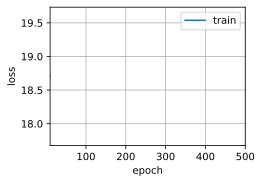

In [50]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = RNNModelScratch(len(vocab), num_hiddens, device, get_params, init_gru_state, gru)
train_ch8(model, train_iter, vocab, lr, num_epochs, device)